<a href="https://colab.research.google.com/github/CentenoGarrido/Challenge-2-TelecomX/blob/main/Challenge_TelecomX_2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Churn de Clientes de la empresa TelecomX
# Implementación/Prueba de modelos de Machine Learning
Se realiza un análisis completo del conjunto de datos de la empresa ficticia TelecomX para predecir la tasa de evasión (Churn). Se incluyen gráficos de matriz de confusión y de importancia de variables para cada modelo. Los modelos utilizados son: Baseline (Dummy), Regresión Logística, K-Nearest Neighbors (KNN), Máquinas de Vectores de Soporte (SVM), Árbol de Decisión, Random Forest y Gradient Boosting. Mediante un proceso automatizado se comparan los diferentes modelos y se escoje al mejor según su combinación de métricas.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                           roc_curve, confusion_matrix, accuracy_score, classification_report)

import warnings
warnings.filterwarnings("ignore")

# Diccionarios de traducción para nombres de columnas y valores
column_translations = {
    'customerID': 'ID Cliente',
    'customer.gender': 'Género',
    'customer.SeniorCitizen': 'Adulto mayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Permanencia (meses)',
    'phone.PhoneService': 'Servicio telefónico',
    'phone.MultipleLines': 'Múltiples líneas',
    'internet.InternetService': 'Servicio Internet',
    'internet.OnlineSecurity': 'Seguridad online',
    'internet.OnlineBackup': 'Respaldo online',
    'internet.DeviceProtection': 'Protección dispositivo',
    'internet.TechSupport': 'Soporte técnico',
    'internet.StreamingTV': 'TV por streaming',
    'internet.StreamingMovies': 'Películas por streaming',
    'account.Contract': 'Tipo contrato',
    'account.PaperlessBilling': 'Facturación sin papel',
    'account.PaymentMethod': 'Método de pago',
    'Churn': 'Abandono',
    'account.Charges.Monthly': 'Cargos mensuales',
    'account.Charges.Total': 'Cargos totales',
    'account.Charges.Daily': 'Cargos diarios'
}

value_translations = {
    # Género
    'Male': 'Masculino',
    'Female': 'Femenino',
    # Valores binarios
    'Yes': 'Sí',
    'No': 'No',
    # Servicios internet
    'DSL': 'DSL',
    'Fiber optic': 'Fibra óptica',
    'No internet service': 'Sin servicio Internet',
    # Múltiples líneas
    'No phone service': 'Sin servicio telefónico',
    # Contratos
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años',
    # Métodos de pago
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
    'Credit card (automatic)': 'Tarjeta de crédito (automática)'
}

def translate_column_name(col_name):
    """Traduce nombres de columnas al español"""
    return column_translations.get(col_name, col_name)

def translate_values(series):
    """Traduce valores de una serie al español"""
    if series.dtype == 'object':
        return series.map(lambda x: value_translations.get(x, x) if pd.notna(x) else x)
    return series

def translate_feature_name(feature_name):
    """Traduce nombres de características creadas por OneHotEncoder"""
    # Para características numéricas
    if feature_name in column_translations:
        return column_translations[feature_name]

    # Para características categóricas codificadas
    for original, translation in column_translations.items():
        if feature_name.startswith(original + '_'):
            value_part = feature_name.replace(original + '_', '')
            translated_value = value_translations.get(value_part, value_part)
            return f'{translation}_{translated_value}'

    # Si no encuentra traducción, devolver el nombre original procesado
    return feature_name.replace('_', ' ').title()

# Configurar matplotlib para mostrar texto en español
rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False



In [27]:
# Carga y Exploración Inicial de Datos

df = pd.read_csv('telecomx-datos-preprocesados.csv')
#df = pd.read_csv('G:/Mi unidad/Colab Notebooks/telecomx-datos-preprocesados.csv')

df_flat = df.copy()
print('\n📊 EXPLORACIÓN INICIAL:')
print(f'Forma del dataset: {df_flat.shape}')
print(f'Columnas: {list(df_flat.columns)}')
print(f'Tipos de datos:\n{df_flat.dtypes}')
print(f'Valores faltantes:\n{df_flat.isnull().sum()}')
print(f'Filas duplicadas: {df_flat.duplicated().sum()}')


📊 EXPLORACIÓN INICIAL:
Forma del dataset: (7043, 22)
Columnas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'account.Charges.Daily']
Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
in

In [28]:
print('\n🧹 LIMPIEZA DE DATOS:')

# Eliminar la columna customerID (no relevante para el análisis)
df_flat = df_flat.drop(columns=['customerID'], errors='ignore')

# Dejar esta columna como las demás, todo en YES o NO, para poder filtrar mejor las categóricas y las númericas
df_flat['customer.SeniorCitizen'] = df_flat['customer.SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Convertir cargos a float
charge_columns = ['account.Charges.Monthly', 'account.Charges.Total', 'account.DailyCharges']

for col in charge_columns:
    if col in df_flat.columns:
        df_flat[col] = pd.to_numeric(df_flat[col], errors='coerce')

# Detectar y manejar outliers
numeric_cols = df_flat.select_dtypes(include=[np.number]).columns
original_shape = df_flat.shape[0]
for col in numeric_cols:
    if df_flat[col].std() > 0:
        df_flat = df_flat[np.abs(df_flat[col] - df_flat[col].mean()) <= (3 * df_flat[col].std())]


print(f'✅ Limpieza completada')
print(f'\tFilas eliminadas por outliers: {original_shape - df_flat.shape[0]}')
print(f'\tForma final: {df_flat.shape}')
print(f'\Valores faltantes después de limpieza: {df_flat.isnull().sum().sum()}')



🧹 LIMPIEZA DE DATOS:
✅ Limpieza completada
	Filas eliminadas por outliers: 0
	Forma final: (7043, 21)
\Valores faltantes después de limpieza: 0



📈 ANÁLISIS EXPLORATORIO DE DATOS:

🎯 DISTRIBUCIÓN DE Churn:

Conteos: Churn
No    5174
Sí    1869
Name: count, dtype: int64

Porcentajes: Churn
No    73.46
Sí    26.54
Name: proportion, dtype: float64


<Figure size 640x480 with 0 Axes>

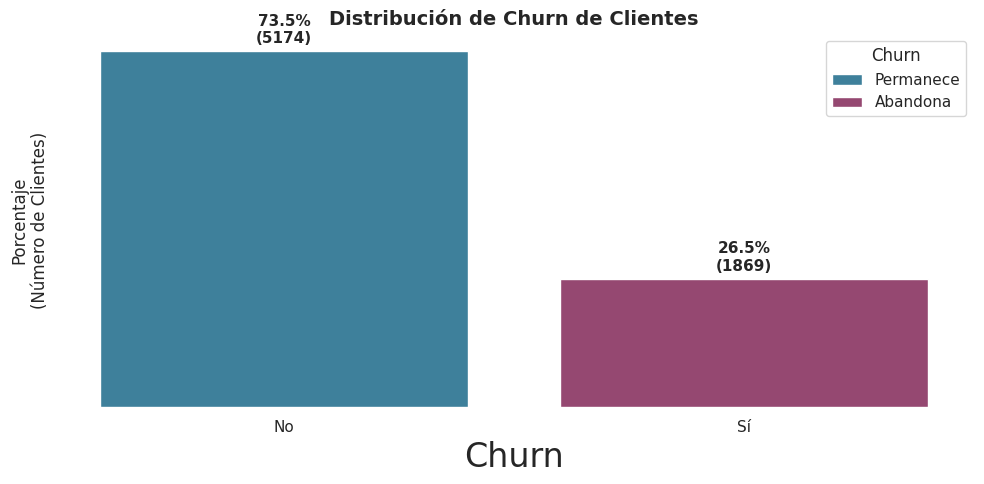


📊 ANÁLISIS POR VARIABLES CATEGÓRICAS:


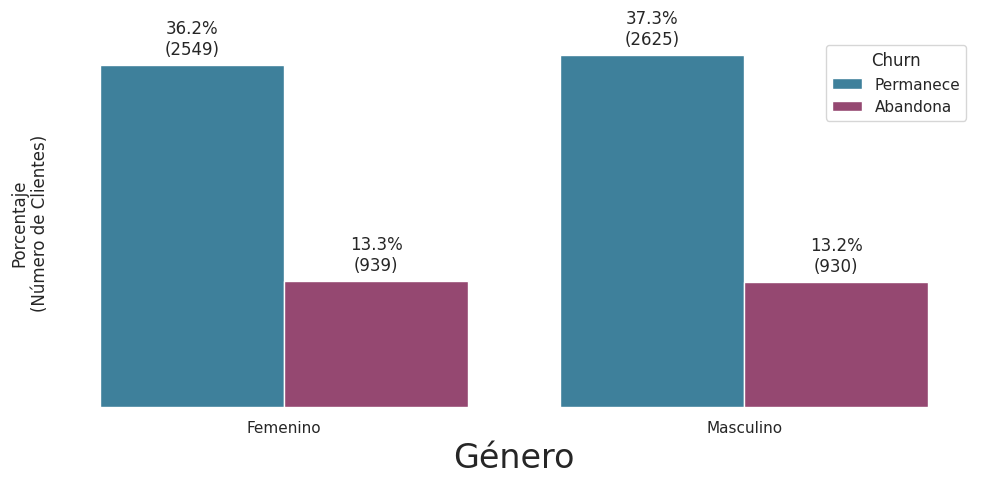

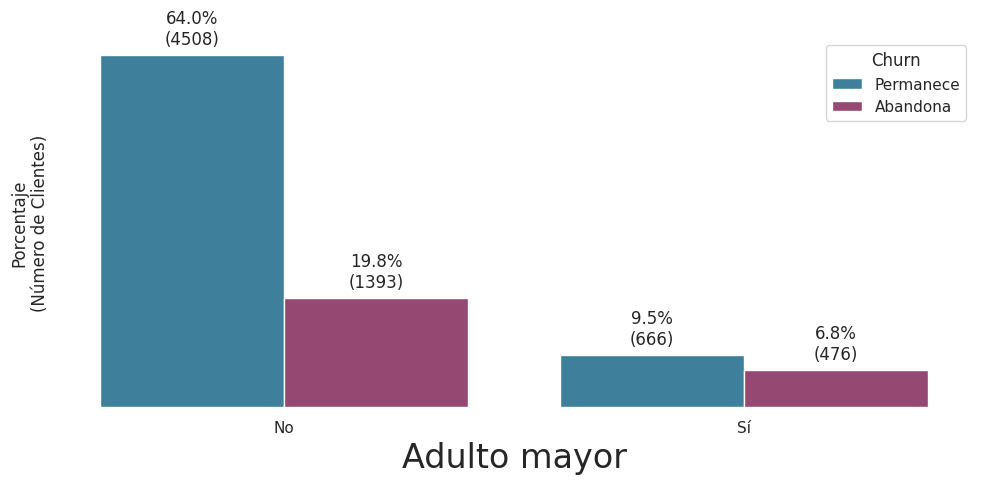

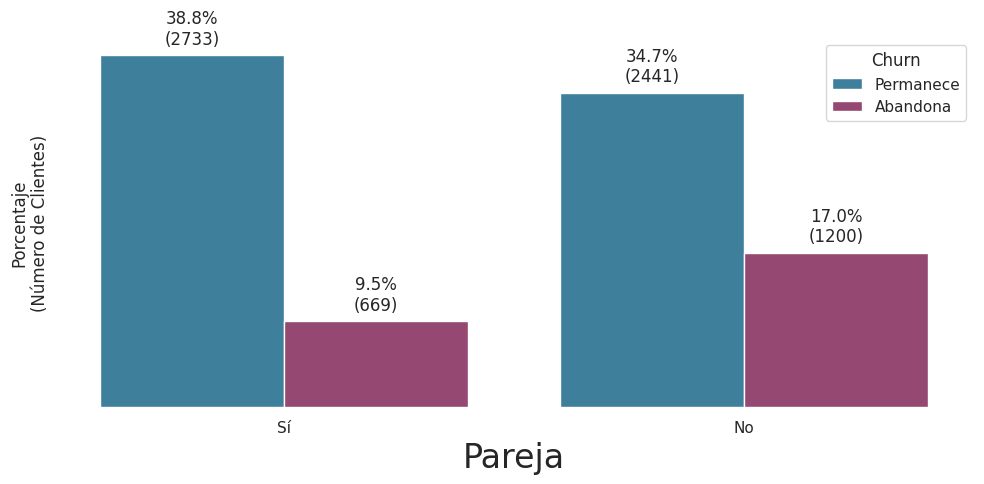

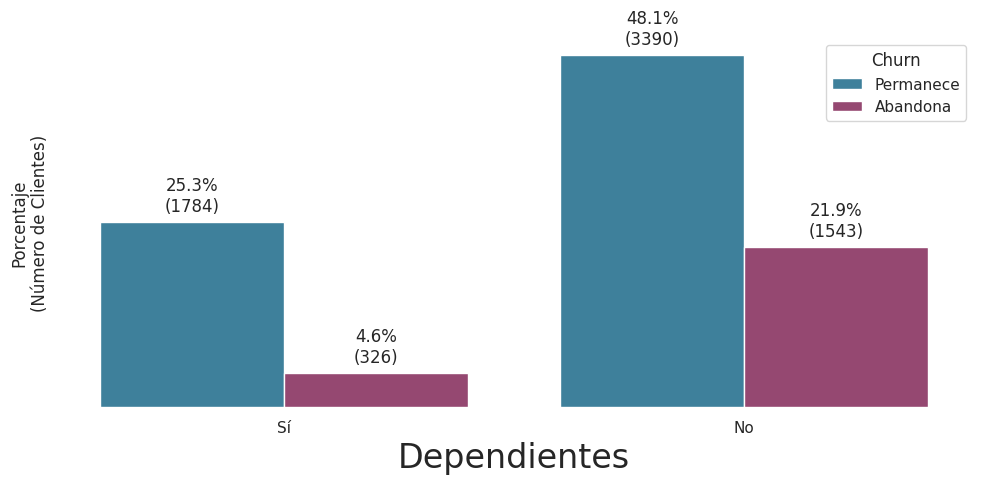

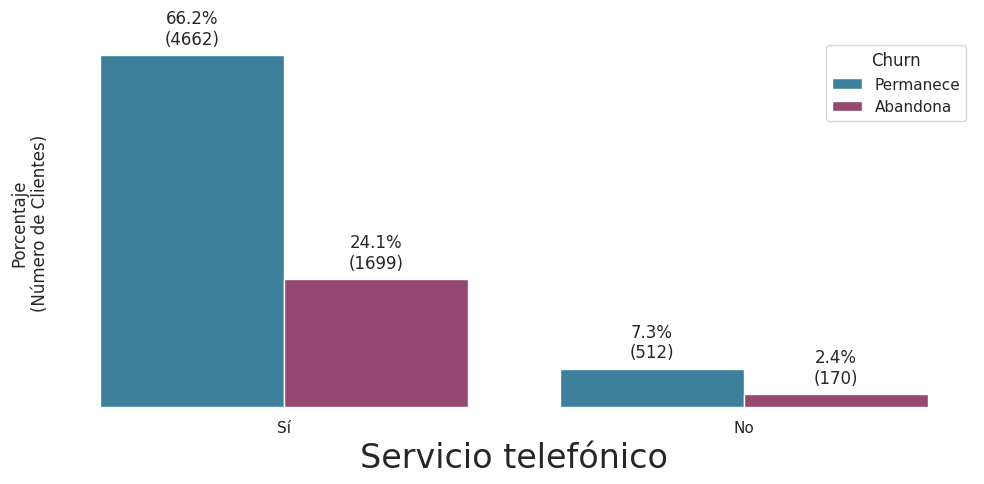

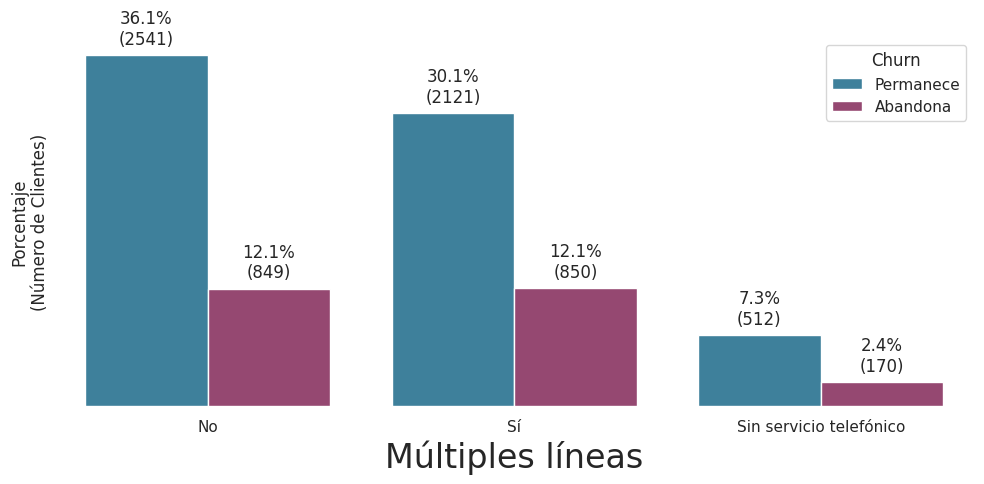

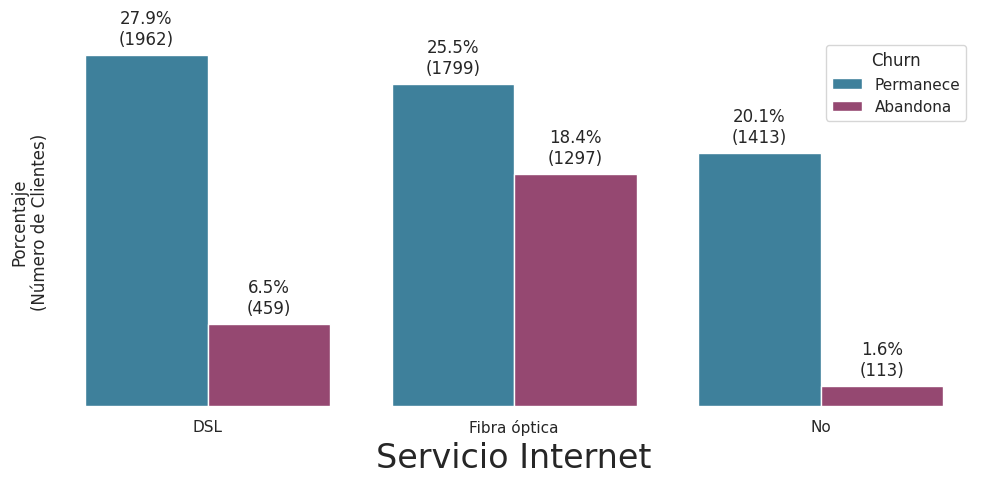

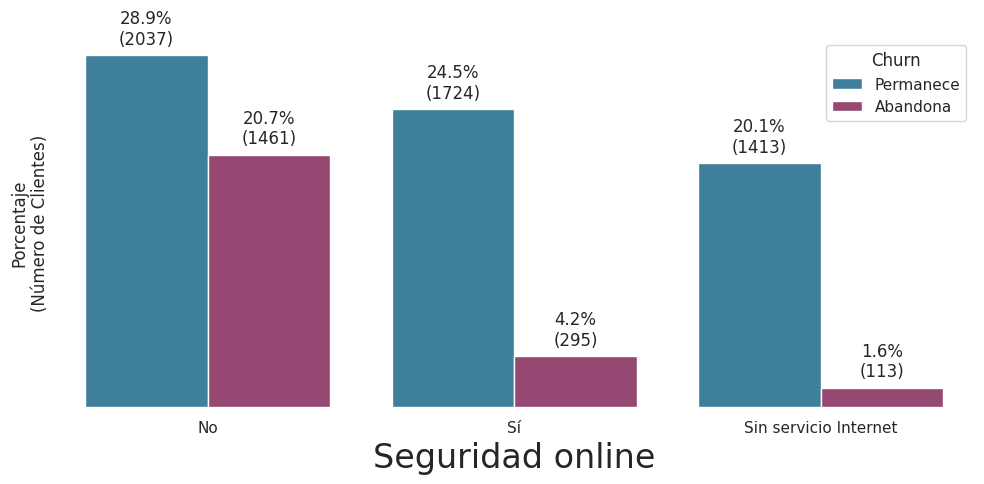

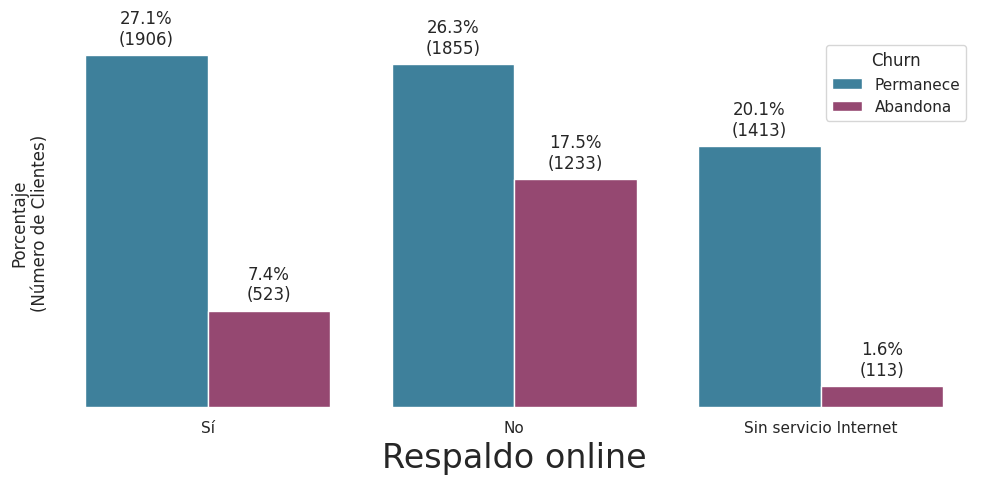

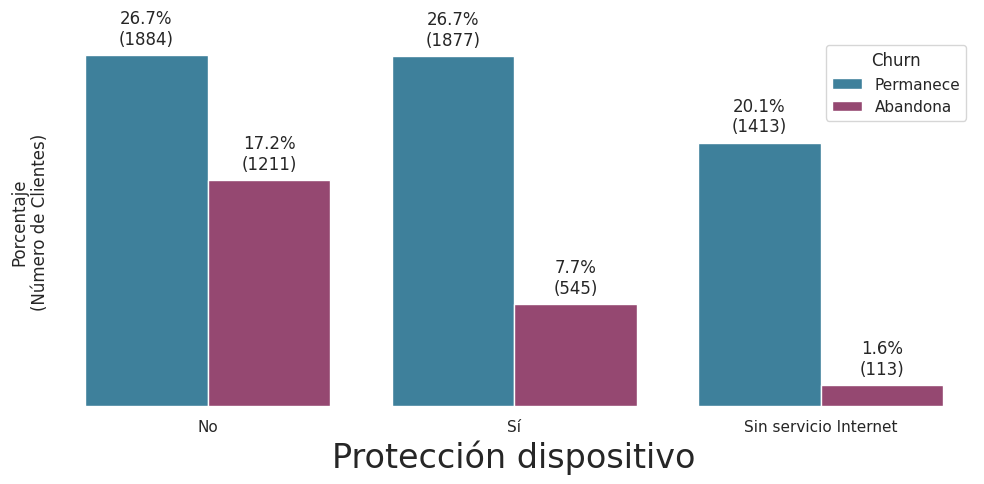

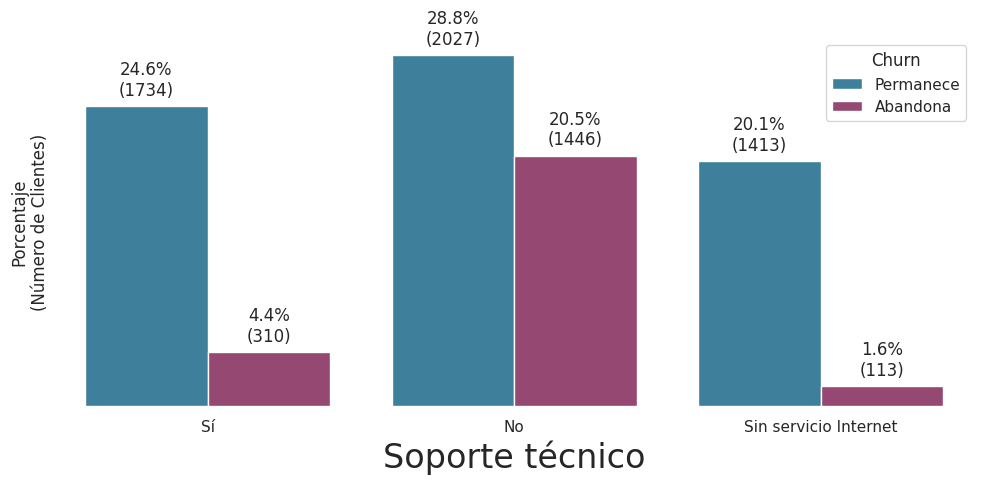

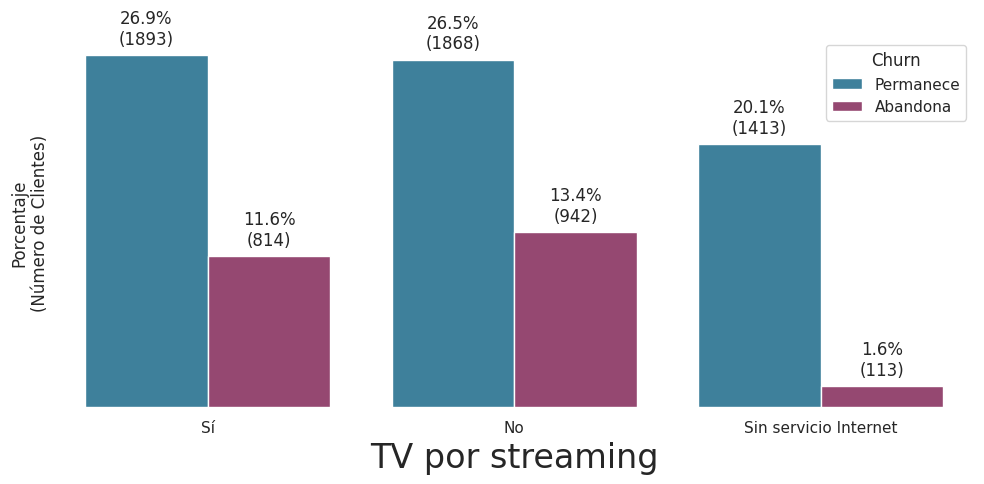

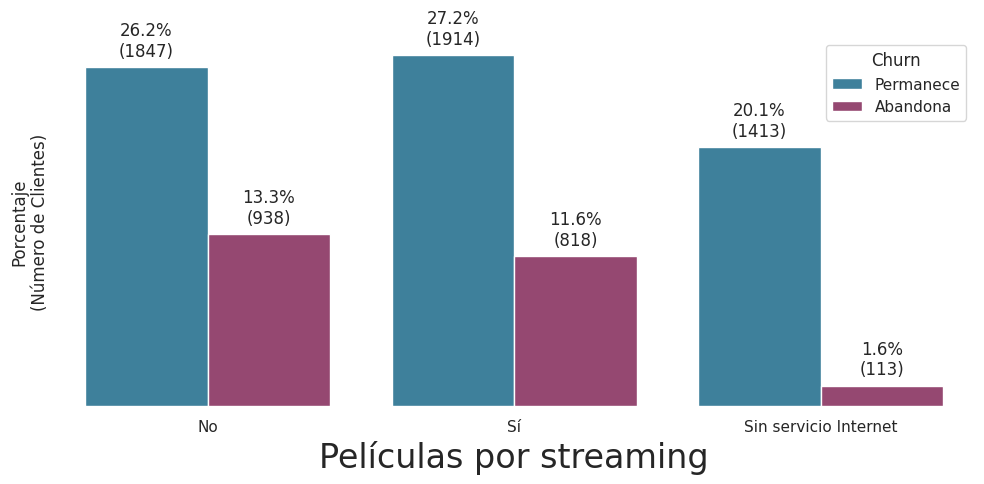

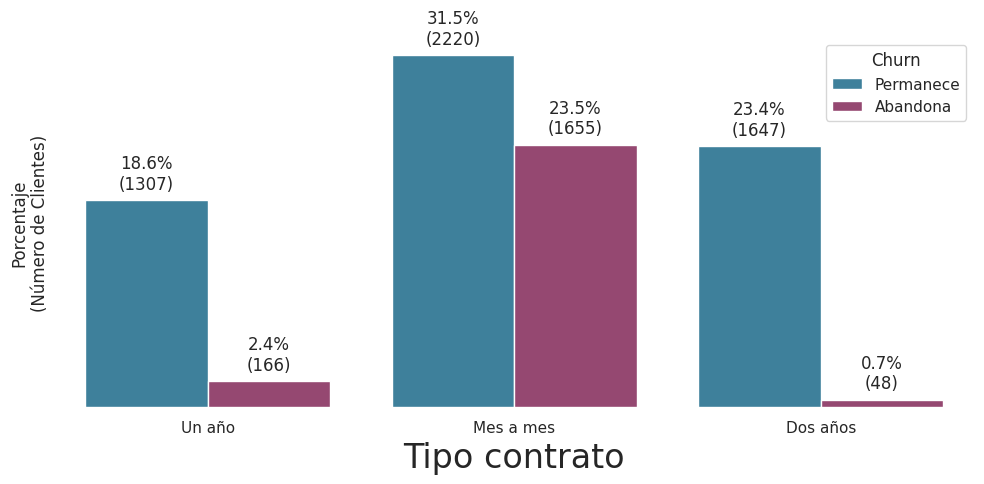

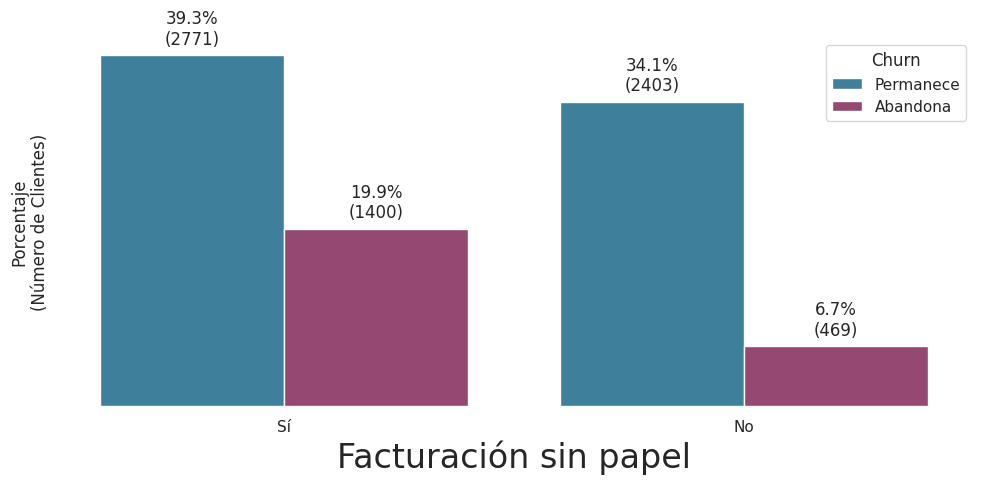

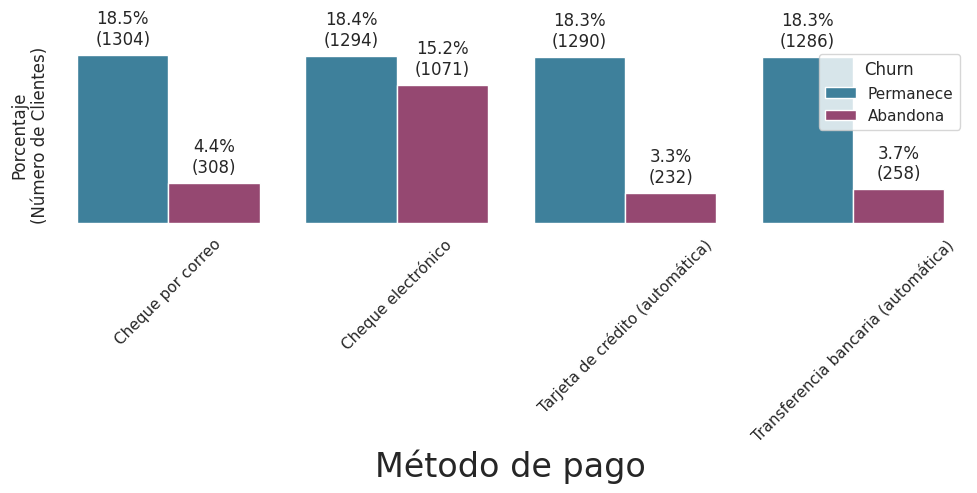


📈 ANÁLISIS DE VARIABLES NUMÉRICAS:


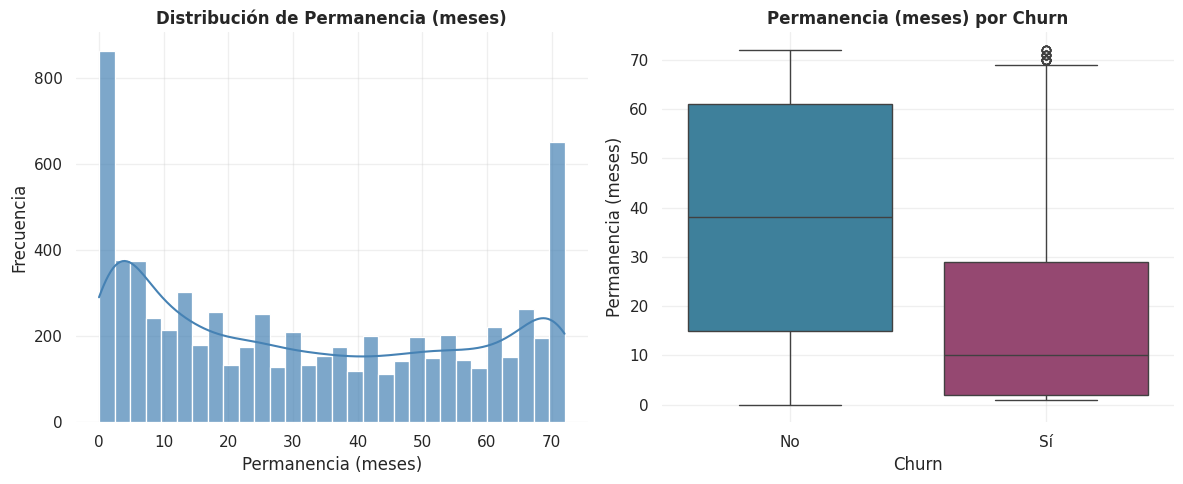

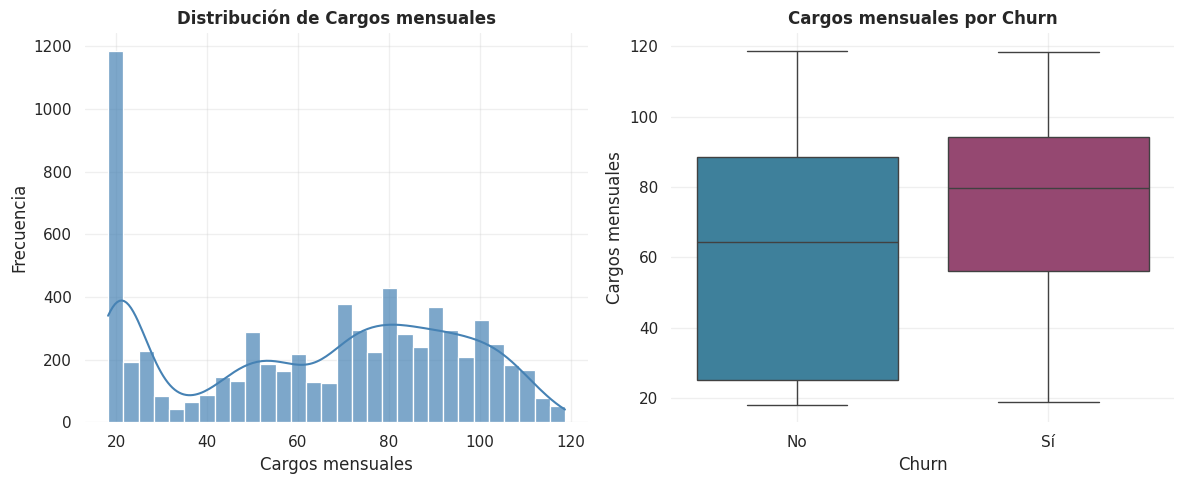

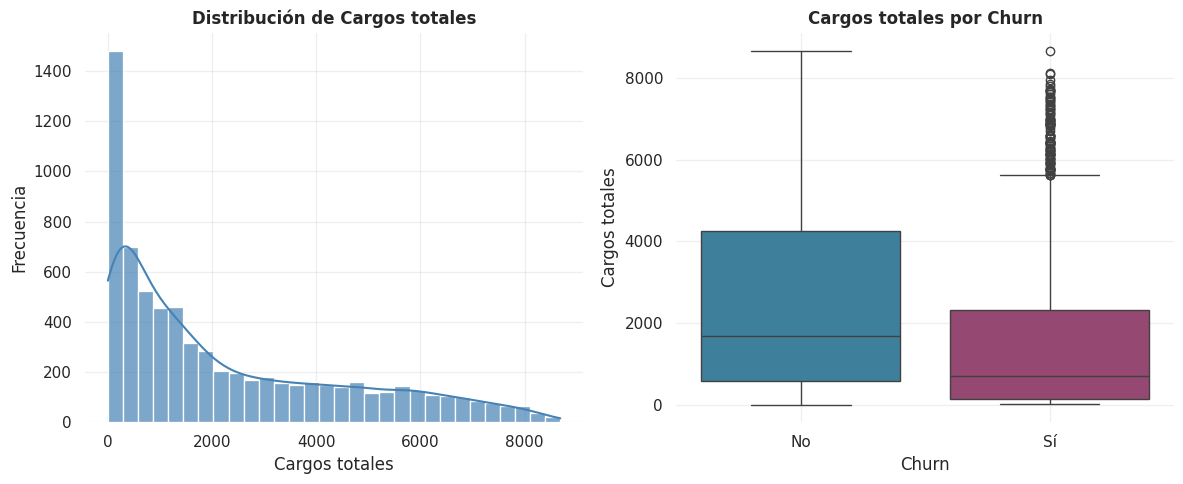

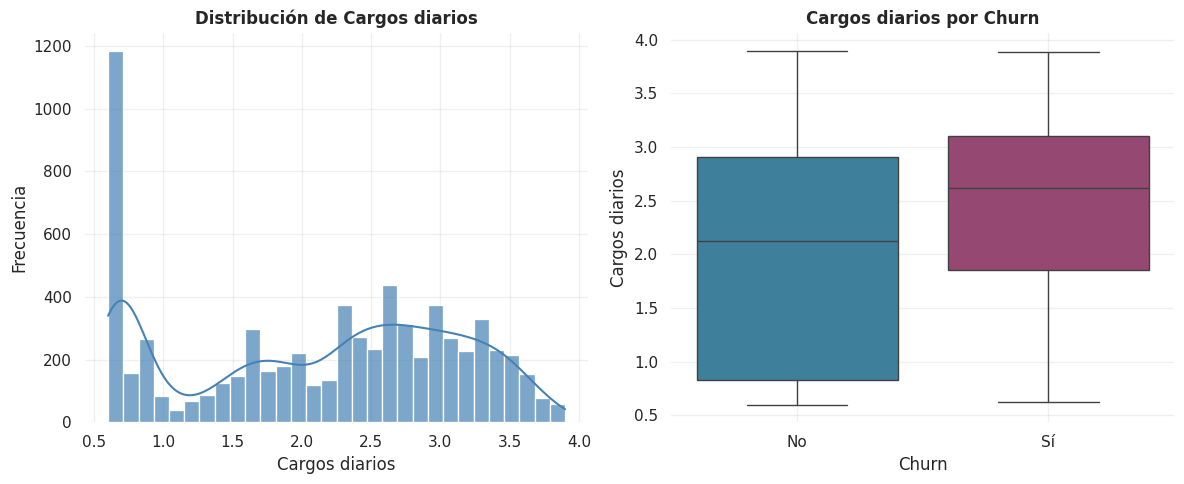


🔗 MATRIZ DE CORRELACIONES:


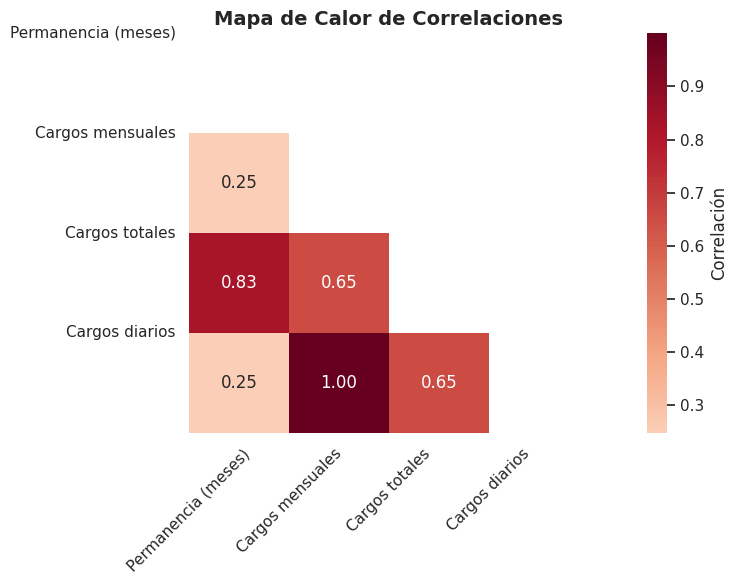

In [29]:
print('\n📈 ANÁLISIS EXPLORATORIO DE DATOS:')

# Configuración global para gráficos.
sns.set_theme(style='white', rc={'axes.grid': False})
sns.set_context('notebook')
sns.despine(trim=True)

# Eliminar todos los spines por defecto
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False

# Crear copia traducida para visualizaciones
df_viz = df_flat.copy()
for col in df_viz.select_dtypes(include=['object']).columns:
    df_viz[col] = translate_values(df_viz[col])

# Distribución de la variable objetivo
print('\n🎯 DISTRIBUCIÓN DE Churn:')
churn_counts = df_viz['Churn'].value_counts()
churn_pct = df_viz['Churn'].value_counts(normalize=True) * 100
print(f'\nConteos: {churn_counts}')
print(f'\nPorcentajes: {churn_pct.round(2)}')

# Visualización de la distribución de Churn
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_viz, x='Churn', palette=['#2E86AB', '#A23B72'])

plt.title('Distribución de Churn de Clientes', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=24)
plt.ylabel('Porcentaje\n(Número de Clientes)', fontsize=12)
plt.legend(title='Churn', labels=['Permanece', 'Abandona'])
ax.yaxis.set_ticks([])

# Añadir etiquetas a las barras
total = len(df_viz)
for i, (patch, count) in enumerate(zip(ax.patches, churn_counts)):
    percentage = f'{(count/total)*100:.1f}%'
    ax.text(patch.get_x() + patch.get_width()/2., patch.get_height() + total*0.01,
            f'{percentage}\n({count})', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis por variables categóricas
categorical_cols = df_viz.select_dtypes(include=['object']).columns
if 'Churn' in categorical_cols:
    categorical_cols = categorical_cols.drop('Churn')

print('\n📊 ANÁLISIS POR VARIABLES CATEGÓRICAS:')
for col in categorical_cols:
    if len(df_viz[col].unique()) <= 8:  # Solo columnas con pocas categorías
        plt.figure(figsize=(10, 5))
        ax = sns.countplot(data=df_viz, x=col, hue='Churn', palette=['#2E86AB', '#A23B72'])
        plt.xlabel(translate_column_name(col), fontsize=24)
        plt.ylabel('Porcentaje\n(Número de Clientes)', fontsize=12)
        plt.xticks(rotation=45 if any(len(str(x)) > 25 for x in df_viz[col].unique()) else 0)
        plt.legend(title='Churn', labels=['Permanece', 'Abandona'])
        ax.yaxis.set_ticks([])
        for container in ax.containers:
                    for p in container:
                        height = p.get_height()
                        if height > 0:
                            percentage = '{:.1f}%'.format(100 * height/total)
                            ax.annotate(f'{percentage}\n({int(height)})', (p.get_x() + p.get_width() / 2., height),
                                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

        plt.tight_layout()
        plt.show()

# Análisis de variables numéricas
print('\n📈 ANÁLISIS DE VARIABLES NUMÉRICAS:')
for col in numeric_cols:
    if len(df_viz[col].dropna()) > 0:
        # Histograma
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(df_viz[col], bins=30, alpha=0.7, kde = True, color='steelblue')
        plt.title(f'Distribución de {translate_column_name(col)}', fontweight='bold')
        plt.xlabel(translate_column_name(col))
        plt.ylabel('Frecuencia')
        plt.grid(True, alpha=0.3)

        # Boxplot por Churn
        plt.subplot(1, 2, 2)
        sns.boxplot(data=df_viz, x='Churn', y=col, palette=['#2E86AB', '#A23B72'])
        plt.title(f'{translate_column_name(col)} por Churn', fontweight='bold')
        plt.xlabel('Churn')
        plt.ylabel(translate_column_name(col))
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Matriz de correlación
if len(numeric_cols) > 1:
    print('\n🔗 MATRIZ DE CORRELACIONES:')
    corr_matrix = df_flat[numeric_cols].corr()

    plt.figure(figsize=(12, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                square=True, fmt='.2f', mask=mask, cbar_kws={'label': 'Correlación'})
    plt.title('Mapa de Calor de Correlaciones', fontsize=14, fontweight='bold')

    # Traducir etiquetas
    translated_labels = [translate_column_name(col) for col in corr_matrix.columns]
    plt.xticks(range(len(translated_labels)), translated_labels, rotation=45)
    plt.yticks(range(len(translated_labels)), translated_labels, rotation=0)

    plt.tight_layout()
    plt.show()


In [30]:
print('\n🤖 PREPARACIÓN DE MODELOS:')

# Codificar la variable objetivo
le = LabelEncoder()
df_flat['Churn_encoded'] = le.fit_transform(df_flat['Churn'])
print(f'Codificación de Abandono: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Separar características y variable objetivo
X = df_flat.drop(['Churn', 'Churn_encoded'], axis=1)
y = df_flat['Churn_encoded']

print(f'Forma del conjunto de características: {X.shape}')
print(f'Distribución de clases: {dict(pd.Series(y).value_counts())}')

# Identificar tipos de columnas
categorical_cols_model = X.select_dtypes(include=['object']).columns
numeric_cols_model = X.select_dtypes(include=[np.number]).columns

print(f'Variables numéricas ({len(numeric_cols_model)}): {list(numeric_cols_model)}')
print(f'Variables categóricas ({len(categorical_cols_model)}): {list(categorical_cols_model)}')

# Crear preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_model),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols_model)
    ],
    remainder='passthrough'
)

# Aplicar preprocesamiento
X_processed = preprocessor.fit_transform(X)

# Obtener nombres de características
if len(categorical_cols_model) > 0:
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols_model)
    feature_names = list(numeric_cols_model) + list(cat_feature_names)
else:
    feature_names = list(numeric_cols_model)

X_processed = pd.DataFrame(X_processed, columns=feature_names)
print(f'Características después del preprocesamiento: {X_processed.shape[1]}')

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')

# Definir modelos
models = {
    'Línea Base (Dummy)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'K-Vecinos Cercanos': KNeighborsClassifier(n_neighbors=5),
    'Máquinas de Vectores de Soporte': SVC(random_state=42, probability=True),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Bosque Aleatorio': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Entrenar modelos
print('\n🎯 ENTRENAMIENTO DE MODELOS:')
for name, model in models.items():
    print(f'Entrenando {name}...', end=' ')
    model.fit(X_train, y_train)
    print('✅')



🤖 PREPARACIÓN DE MODELOS:
Codificación de Abandono: {'No': np.int64(0), 'Yes': np.int64(1)}
Forma del conjunto de características: (7043, 20)
Distribución de clases: {0: np.int64(5174), 1: np.int64(1869)}
Variables numéricas (4): ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'account.Charges.Daily']
Variables categóricas (16): ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']
Características después del preprocesamiento: 31
Conjunto de entrenamiento: 5634 muestras
Conjunto de prueba: 1409 muestras

🎯 ENTRENAMIENTO DE MODELOS:
Entrenando Línea Base (Dummy)... ✅
Entrenando Regresión Logística... ✅
Entrenando K-Vecinos Cercano


📊 EVALUACIÓN DE MODELOS:

🔍 Evaluando Línea Base (Dummy):
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                   1035                   0
Real: Abandona                       374                   0


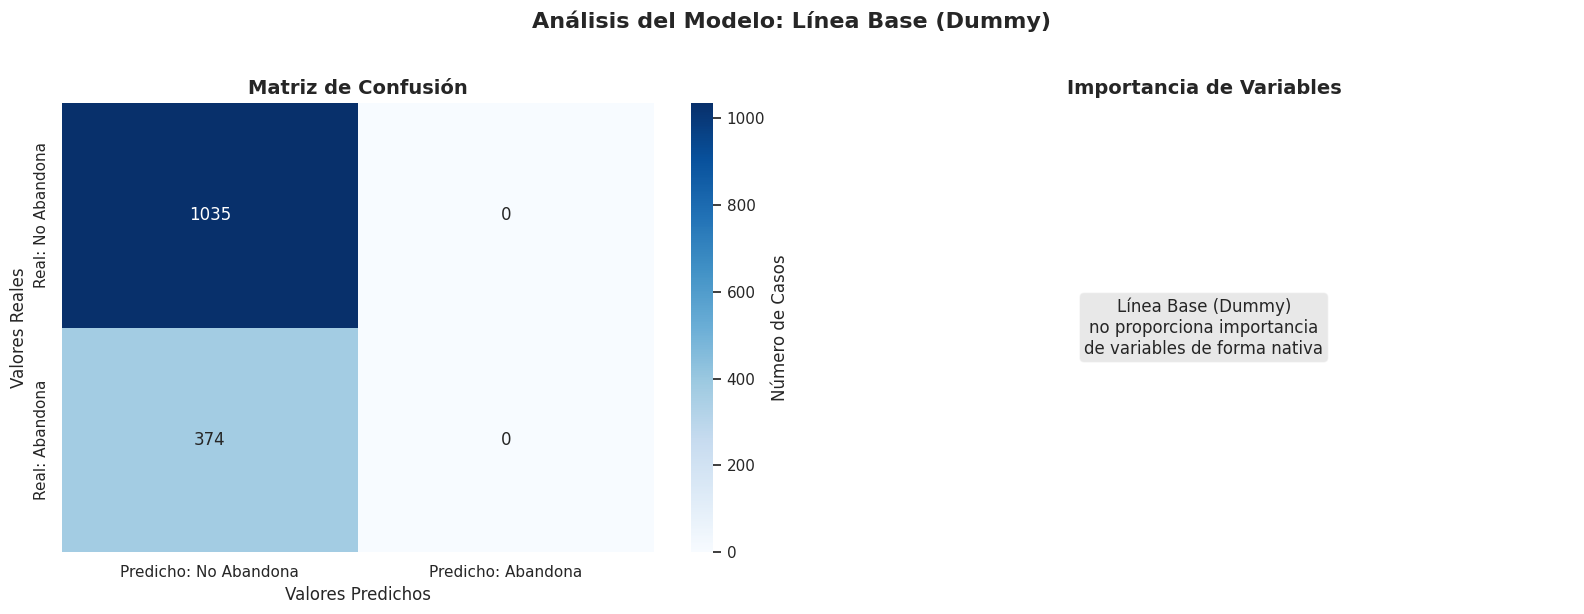

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.73      1.00      0.85      1035
    Abandona       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409


🔍 Evaluando Regresión Logística:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    923                 112
Real: Abandona                       179                 195


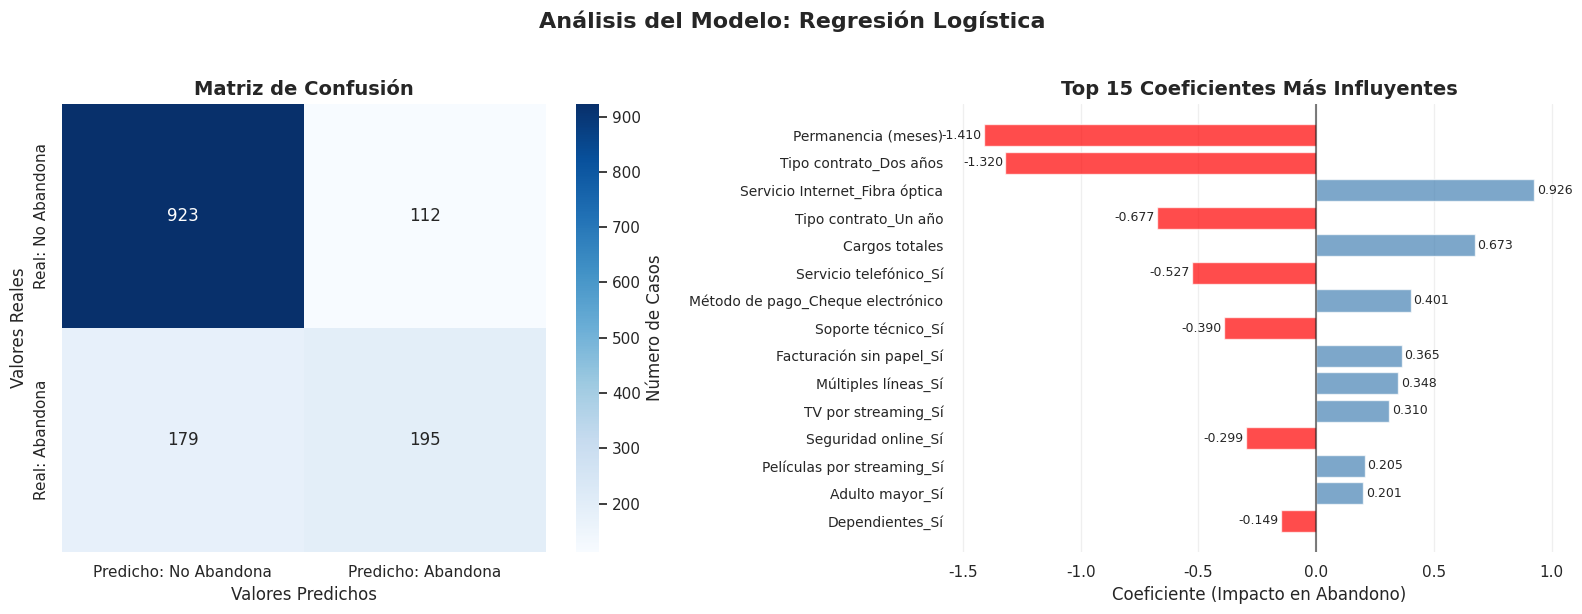

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.84      0.89      0.86      1035
    Abandona       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


🔍 Evaluando K-Vecinos Cercanos:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    883                 152
Real: Abandona                       176                 198


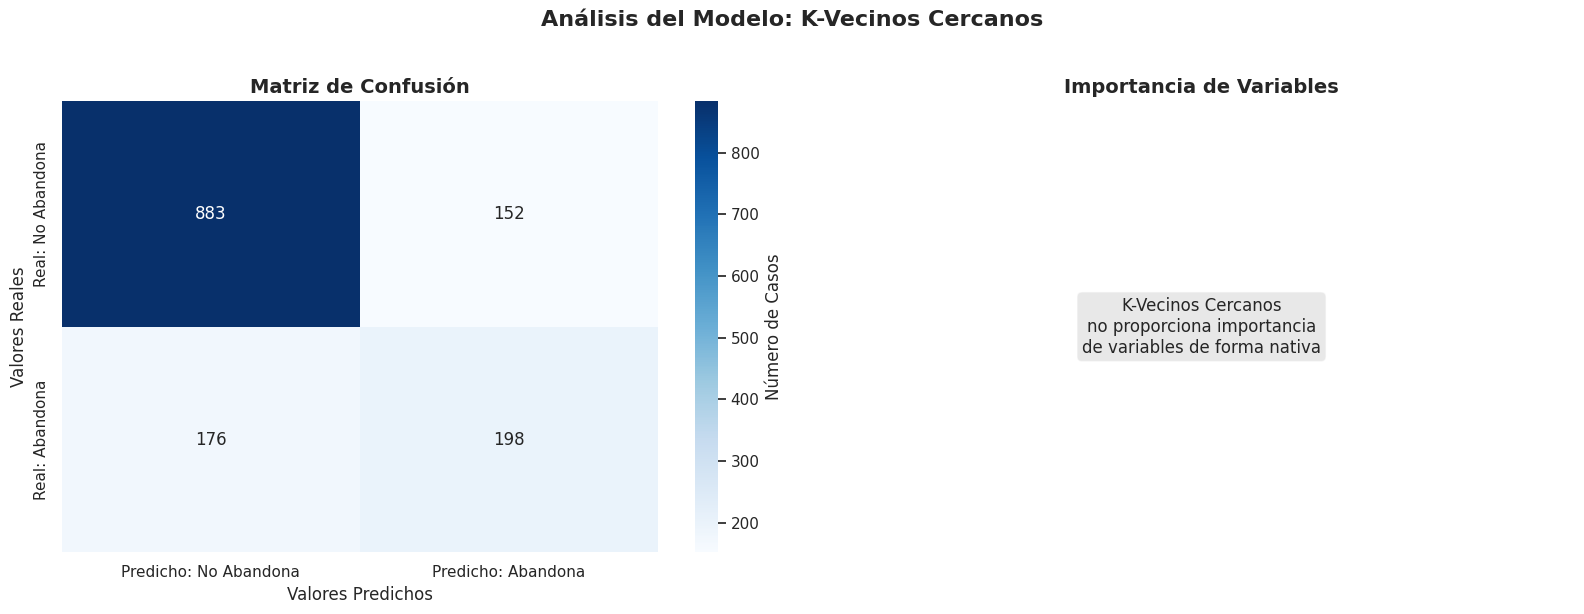

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.83      0.85      0.84      1035
    Abandona       0.57      0.53      0.55       374

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.76      1409


🔍 Evaluando Máquinas de Vectores de Soporte:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    949                  86
Real: Abandona                       198                 176


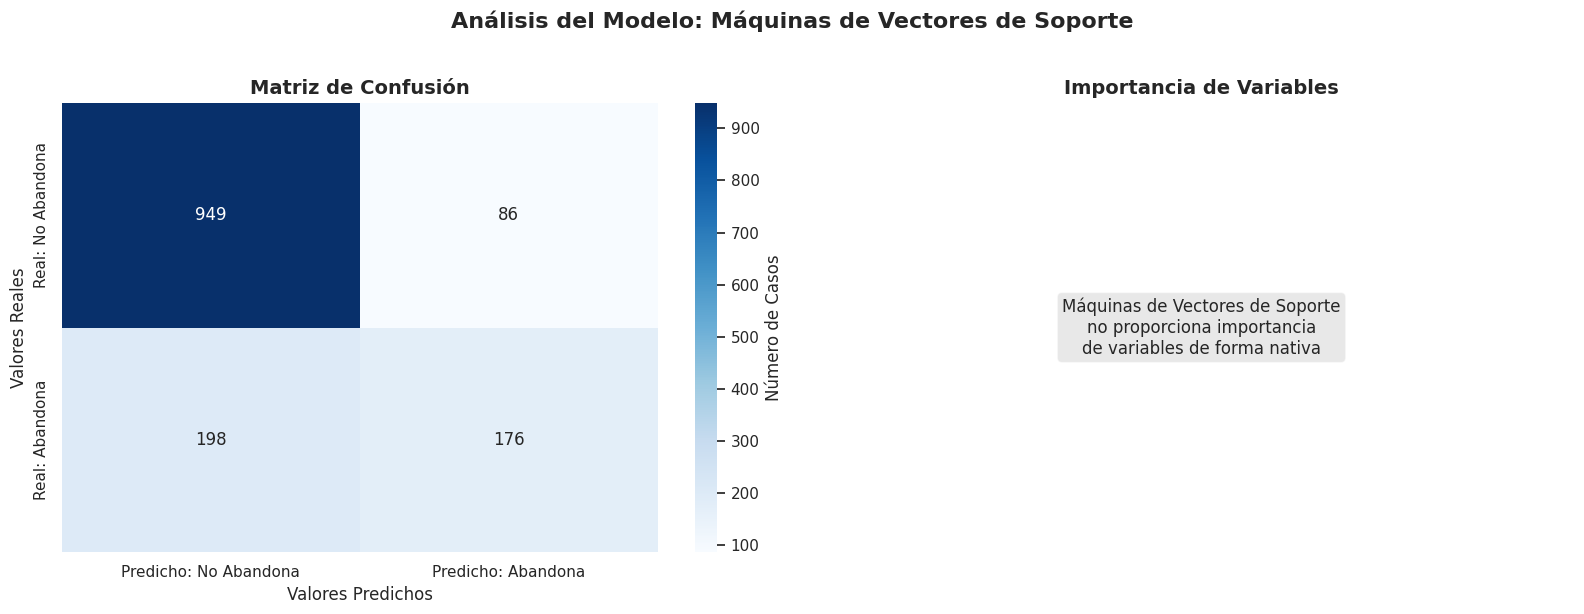

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.83      0.92      0.87      1035
    Abandona       0.67      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409


🔍 Evaluando Árbol de Decisión:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    898                 137
Real: Abandona                       196                 178


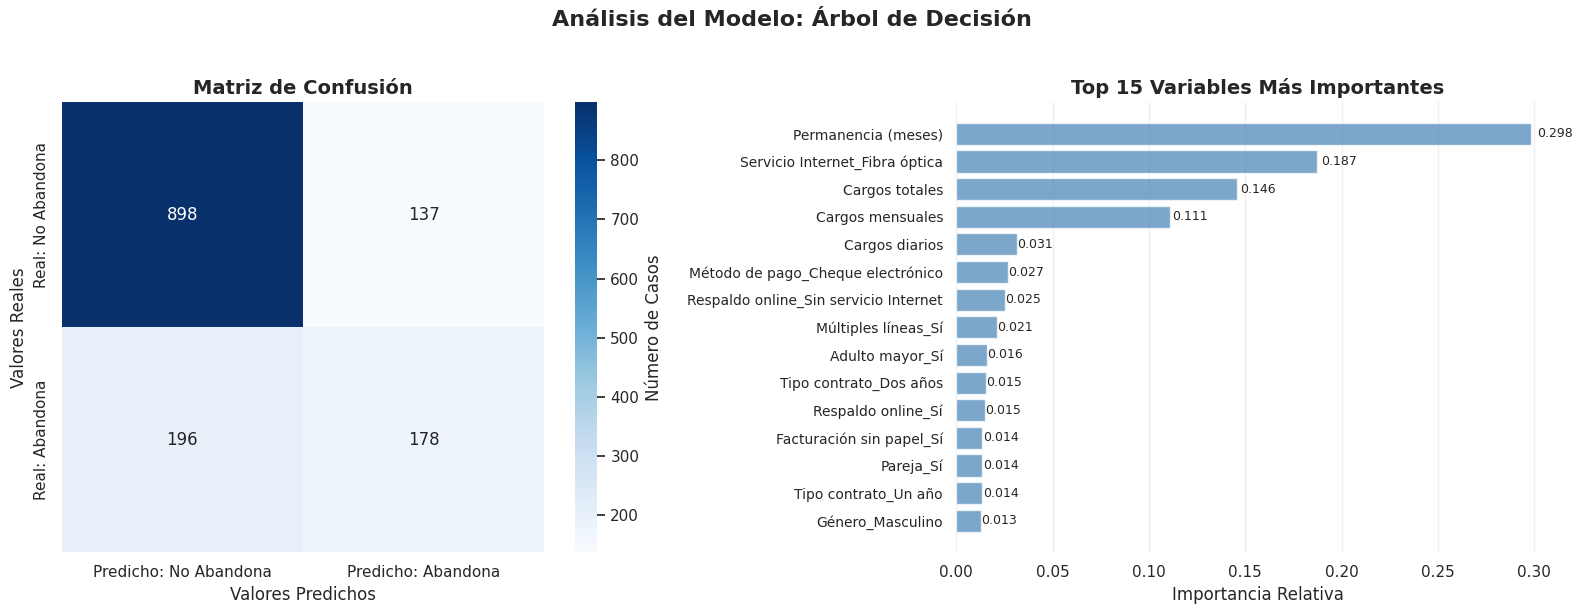

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.82      0.87      0.84      1035
    Abandona       0.57      0.48      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.76      1409


🔍 Evaluando Bosque Aleatorio:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    929                 106
Real: Abandona                       195                 179


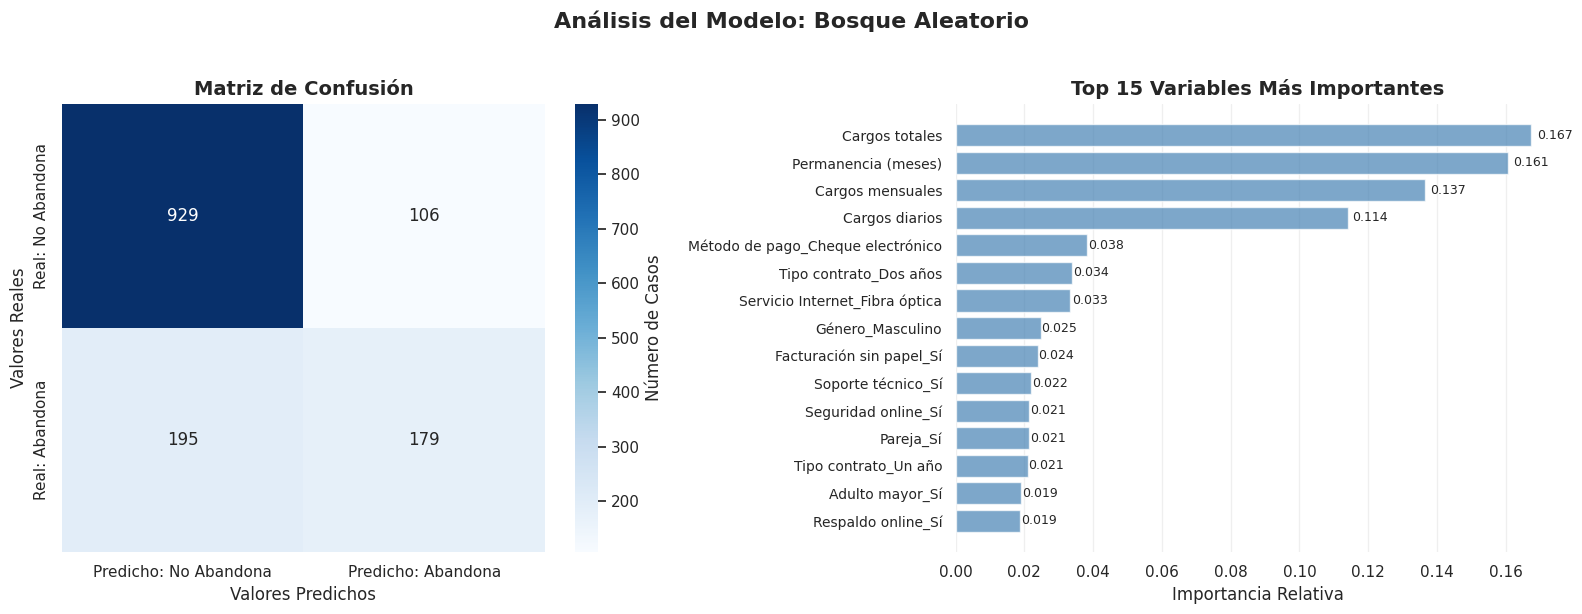

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.83      0.90      0.86      1035
    Abandona       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


🔍 Evaluando Gradient Boosting:
Matriz de Confusión:
                   Predicho: No Abandona  Predicho: Abandona
Real: No Abandona                    931                 104
Real: Abandona                       184                 190


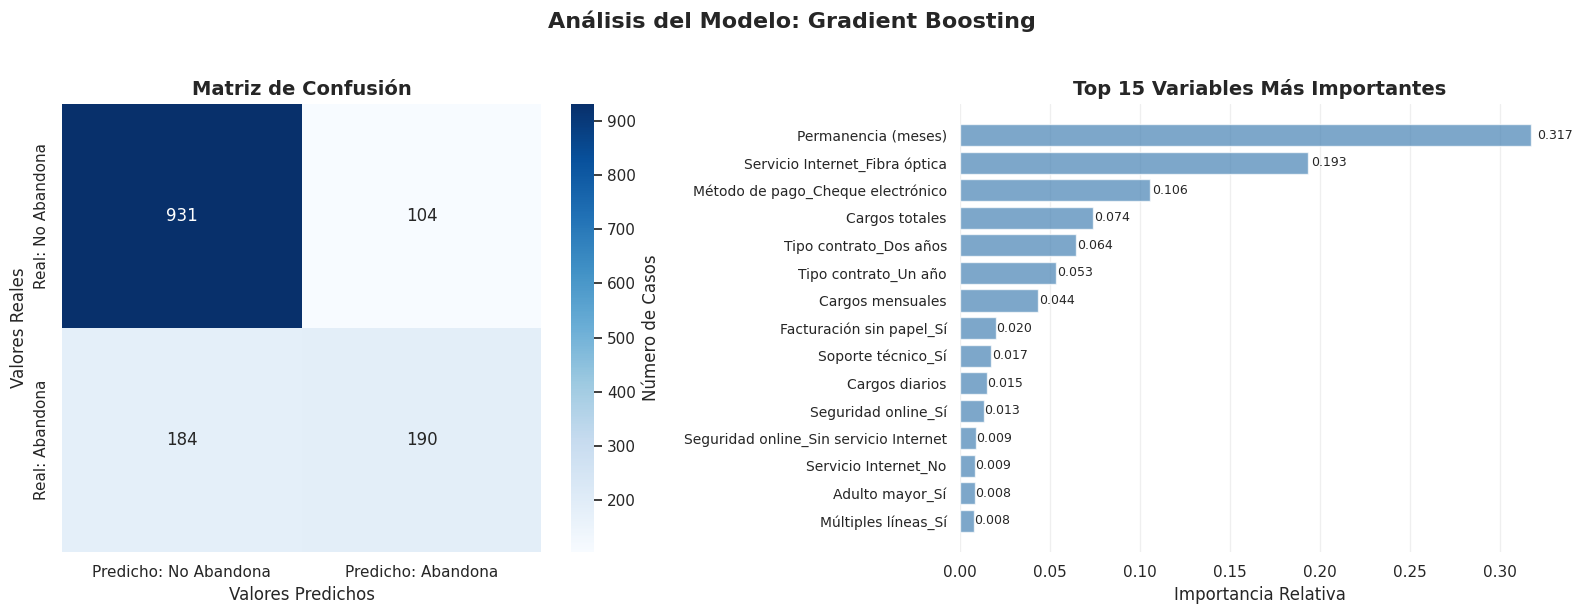

Reporte de Clasificación:
              precision    recall  f1-score   support

 No Abandona       0.83      0.90      0.87      1035
    Abandona       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



In [31]:
print('\n📊 EVALUACIÓN DE MODELOS:')

results = {}
train_results = {}

for name, model in models.items():
    print(f'\n🔍 Evaluando {name}:')

    # Predicciones en conjunto de prueba
    y_pred = model.predict(X_test)

    # Obtener probabilidades
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred

    # Métricas de prueba
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0.5

    results[name] = {
        'Exactitud': accuracy,
        'Precisión': precision,
        'Sensibilidad': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    }

    # Métricas de entrenamiento
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

    if hasattr(model, 'predict_proba'):
        train_prob = model.predict_proba(X_train)[:, 1]
    elif hasattr(model, 'decision_function'):
        train_prob = model.decision_function(X_train)
    else:
        train_prob = y_train_pred

    try:
        train_auc = roc_auc_score(y_train, train_prob)
    except:
        train_auc = 0.5

    train_results[name] = {
        'Exactitud': train_accuracy,
        'Precisión': train_precision,
        'Sensibilidad': train_recall,
        'F1-Score': train_f1,
        'AUC-ROC': train_auc
    }

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,
                        index=['Real: No Abandona', 'Real: Abandona'],
                        columns=['Predicho: No Abandona', 'Predicho: Abandona'])

    print('Matriz de Confusión:')
    print(cm_df)

    # Visualizaciones
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Análisis del Modelo: {name}', fontsize=16, fontweight='bold', y=1.02)

    # Matriz de confusión visual
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax1,
                cbar_kws={'label': 'Número de Casos'})
    ax1.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Valores Reales', fontsize=12)
    ax1.set_xlabel('Valores Predichos', fontsize=12)

    # Importancia de variables
    if name in ['Árbol de Decisión', 'Bosque Aleatorio', 'Gradient Boosting']:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-15:]
        selected_importances = importances[indices]
        selected_features = [translate_feature_name(feature_names[i]) for i in indices]

        bars = ax2.barh(range(len(indices)), selected_importances, align='center',
                       color='steelblue', alpha=0.7)
        ax2.set_yticks(range(len(indices)))
        ax2.set_yticklabels(selected_features, fontsize=10)
        ax2.set_xlabel('Importancia Relativa', fontsize=12)
        ax2.set_title('Top 15 Variables Más Importantes', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')

        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', ha='left', va='center', fontsize=9)

    elif name == 'Regresión Logística':
        coefs = model.coef_[0]
        indices = np.argsort(np.abs(coefs))[-15:]
        selected_coefs = coefs[indices]
        selected_features = [translate_feature_name(feature_names[i]) for i in indices]

        colors = ['red' if x < 0 else 'steelblue' for x in selected_coefs]
        bars = ax2.barh(range(len(indices)), selected_coefs, align='center',
                       color=colors, alpha=0.7)
        ax2.set_yticks(range(len(indices)))
        ax2.set_yticklabels(selected_features, fontsize=10)
        ax2.set_xlabel('Coeficiente (Impacto en Abandono)', fontsize=12)
        ax2.set_title('Top 15 Coeficientes Más Influyentes', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)

        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)

    else:
        ax2.text(0.5, 0.5, f'{name}\nno proporciona importancia\nde variables de forma nativa',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=12, transform=ax2.transAxes,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
        ax2.set_title('Importancia de Variables', fontsize=14, fontweight='bold')
        ax2.set_xticks([])
        ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

    # Reporte de clasificación
    print(f'Reporte de Clasificación:')
    target_names = ['No Abandona', 'Abandona']
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))



RESUMEN COMPARATIVO DE MODELOS

Métricas en Conjunto de PRUEBA:
                                 Exactitud  Precisión  Sensibilidad  F1-Score  \
Línea Base (Dummy)                  0.7346     0.0000        0.0000    0.0000   
Regresión Logística                 0.7935     0.6352        0.5214    0.5727   
K-Vecinos Cercanos                  0.7672     0.5657        0.5294    0.5470   
Máquinas de Vectores de Soporte     0.7984     0.6718        0.4706    0.5535   
Árbol de Decisión                   0.7637     0.5651        0.4759    0.5167   
Bosque Aleatorio                    0.7864     0.6281        0.4786    0.5432   
Gradient Boosting                   0.7956     0.6463        0.5080    0.5689   

                                 AUC-ROC  
Línea Base (Dummy)                0.5000  
Regresión Logística               0.8431  
K-Vecinos Cercanos                0.7814  
Máquinas de Vectores de Soporte   0.8043  
Árbol de Decisión                 0.7560  
Bosque Aleatorio            

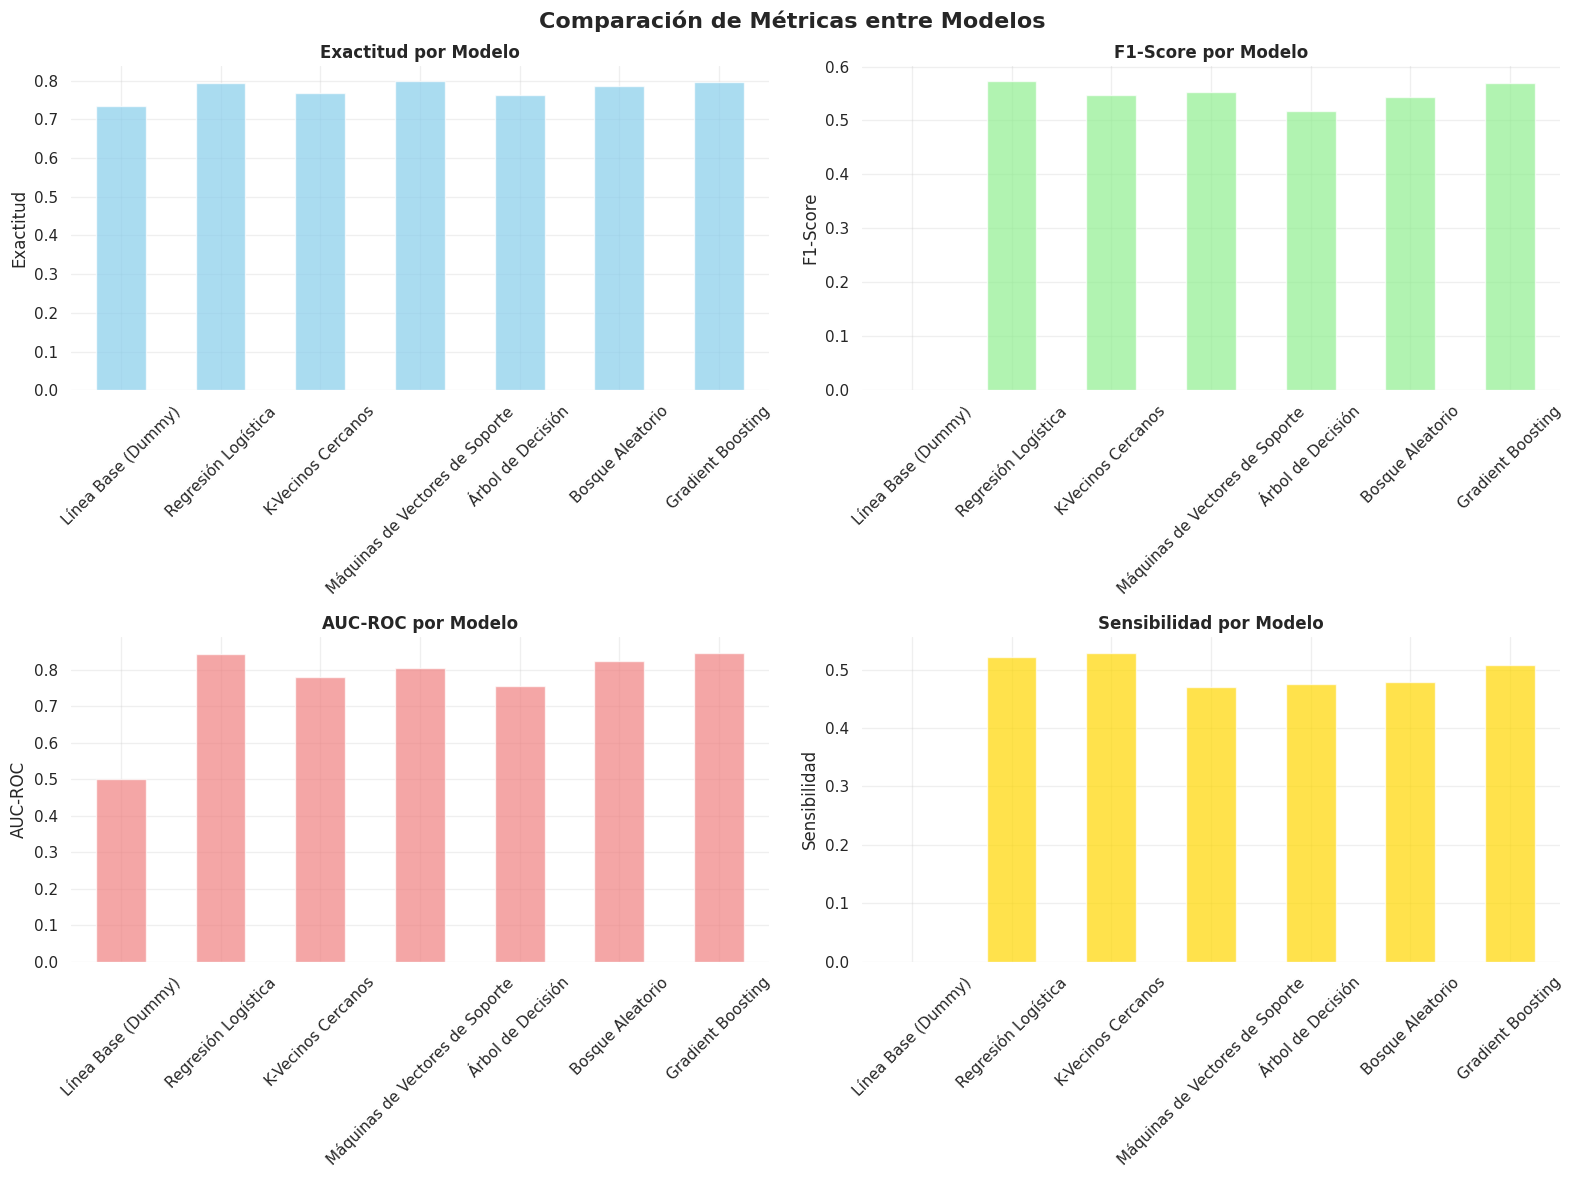


🏆 MEJOR MODELO: Gradient Boosting
   AUC-ROC: 0.8471
   F1-Score: 0.5689
   Sensibilidad: 0.5080


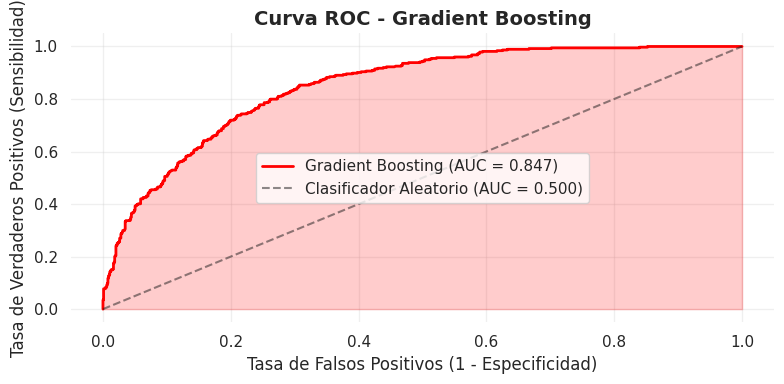

In [32]:
print('\n' + '='*80)
print('RESUMEN COMPARATIVO DE MODELOS')
print('='*80)

# DataFrames de resultados
results_df = pd.DataFrame(results).T
train_results_df = pd.DataFrame(train_results).T

print('\nMétricas en Conjunto de PRUEBA:')
print(results_df.round(4))

print('\nMétricas en Conjunto de ENTRENAMIENTO:')
print(train_results_df.round(4))

# Análisis de overfitting/underfitting
print('\nANÁLISIS DE OVERFITTING/UNDERFITTING:')
print('-' * 50)
diff_df = train_results_df - results_df
for model_name in diff_df.index:
    accuracy_diff = diff_df.loc[model_name, 'Exactitud']
    f1_diff = diff_df.loc[model_name, 'F1-Score']

    if accuracy_diff > 0.05 or f1_diff > 0.05:
        print(f'⚠️  {model_name}: Posible OVERFITTING')
        print(f'   Diferencia Exactitud: {accuracy_diff:.3f}, F1-Score: {f1_diff:.3f}')
    elif accuracy_diff < -0.02:
        print(f'⚠️  {model_name}: Posible UNDERFITTING')
        print(f'   Diferencia Exactitud: {accuracy_diff:.3f}')
    else:
        print(f'✅ {model_name}: Buen balance')

# Gráfico comparativo
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación de Métricas entre Modelos', fontsize=16, fontweight='bold')

results_df['Exactitud'].plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_title('Exactitud por Modelo', fontweight='bold')
ax1.set_ylabel('Exactitud')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

results_df['F1-Score'].plot(kind='bar', ax=ax2, color='lightgreen', alpha=0.7)
ax2.set_title('F1-Score por Modelo', fontweight='bold')
ax2.set_ylabel('F1-Score')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

results_df['AUC-ROC'].plot(kind='bar', ax=ax3, color='lightcoral', alpha=0.7)
ax3.set_title('AUC-ROC por Modelo', fontweight='bold')
ax3.set_ylabel('AUC-ROC')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

results_df['Sensibilidad'].plot(kind='bar', ax=ax4, color='gold', alpha=0.7)
ax4.set_title('Sensibilidad por Modelo', fontweight='bold')
ax4.set_ylabel('Sensibilidad')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar mejor modelo
best_model_name = results_df['AUC-ROC'].idxmax()
best_auc = results_df.loc[best_model_name, 'AUC-ROC']

print(f'\n🏆 MEJOR MODELO: {best_model_name}')
print(f'   AUC-ROC: {best_auc:.4f}')
print(f'   F1-Score: {results_df.loc[best_model_name, "F1-Score"]:.4f}')
print(f'   Sensibilidad: {results_df.loc[best_model_name, "Sensibilidad"]:.4f}')

# Curva ROC del mejor modelo
best_model = models[best_model_name]
if hasattr(best_model, 'predict_proba'):
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, 'decision_function'):
    y_prob_best = best_model.decision_function(X_test)
else:
    print("El mejor modelo no soporta curvas ROC")
    y_prob_best = None

if y_prob_best is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
    plt.figure(figsize=(8, 4))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {best_auc:.3f})',
             linewidth=2, color='red')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador Aleatorio (AUC = 0.500)')
    plt.fill_between(fpr, tpr, alpha=0.2, color='red')

    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
    plt.title(f'Curva ROC - {best_model_name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [33]:
# ANÁLISIS DE INSIGHTS DE NEGOCIO

print('\n' + '='*60)
print('INSIGHTS DE NEGOCIO')
print('='*60)

# Análisis de factores más importantes
print('\n🔍 FACTORES CLAVE QUE INFLUYEN EN EL ABANDONO:')

if best_model_name in ['Árbol de Decisión', 'Bosque Aleatorio', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    feature_importance = list(zip(feature_names, importances))
    feature_importance.sort(key=lambda x: x[1], reverse=True)

    print('\nTop 10 Variables Más Importantes:')
    for i, (feature, importance) in enumerate(feature_importance[:10], 1):
        translated_name = translate_feature_name(feature)
        print(f'{i:2d}. {translated_name:<40} {importance:.4f}')

elif best_model_name == 'Regresión Logística':
    coefs = best_model.coef_[0]
    feature_coef = list(zip(feature_names, coefs))

    # Factores que aumentan abandono (coeficientes positivos)
    positive_factors = [(f, c) for f, c in feature_coef if c > 0]
    positive_factors.sort(key=lambda x: x[1], reverse=True)

    # Factores que reducen abandono (coeficientes negativos)
    negative_factors = [(f, c) for f, c in feature_coef if c < 0]
    negative_factors.sort(key=lambda x: abs(x[1]), reverse=True)

    print('\nFactores que AUMENTAN la probabilidad de abandono:')
    for i, (feature, coef) in enumerate(positive_factors[:5], 1):
        translated_name = translate_feature_name(feature)
        print(f'{i}. {translated_name:<40} +{coef:.4f}')

    print('\nFactores que REDUCEN la probabilidad de abandono:')
    for i, (feature, coef) in enumerate(negative_factors[:5], 1):
        translated_name = translate_feature_name(feature)
        print(f'{i}. {translated_name:<40} {coef:.4f}')

# Análisis estadístico por abandono
print('\n📊 ANÁLISIS ESTADÍSTICO POR SEGMENTO:')

abandono_stats = df_viz.groupby('Churn').agg({
    col: ['mean', 'median'] for col in df_viz.select_dtypes(include=[np.number]).columns
}).round(2)

for col in df_viz.select_dtypes(include=[np.number]).columns:
    col_translated = translate_column_name(col)
    no_abandono_mean = abandono_stats[(col, 'mean')]['No']
    abandono_mean = abandono_stats[(col, 'mean')]['Sí']

    if abs(no_abandono_mean - abandono_mean) > 0.01:  # Solo diferencias significativas
        print(f'\n{col_translated}:')
        print(f'  - No Abandona: {no_abandono_mean}')
        print(f'  - Abandona: {abandono_mean}')
        print(f'  - Diferencia: {abandono_mean - no_abandono_mean:.2f}')

# =====================================================================================
# MÉTRICAS DE NEGOCIO Y ROI
# =====================================================================================

print('\n💰 ESTIMACIÓN DE IMPACTO ECONÓMICO:')

# Cálculo de ROI
total_customers = len(df_viz)
churn_rate = len(df_viz[df_viz['Churn'] == 'Sí']) / total_customers
avg_customer_value = 50  # Valor promedio mensual por cliente.
retention_cost = 20     # Costo promedio de retención por cliente.
acquisition_cost = 100  # Costo de adquirir un nuevo cliente.

# Métricas del mejor modelo
best_recall = results_df.loc[best_model_name, 'Sensibilidad']
best_precision = results_df.loc[best_model_name, 'Precisión']

# Cálculos de impacto
customers_at_risk = int(total_customers * churn_rate)
correctly_identified = int(customers_at_risk * best_recall)
false_positives = int((correctly_identified / best_precision) - correctly_identified) if best_precision > 0 else 0

monthly_savings = correctly_identified * avg_customer_value
monthly_retention_cost = (correctly_identified + false_positives) * retention_cost
net_monthly_benefit = monthly_savings - monthly_retention_cost
annual_benefit = net_monthly_benefit * 12

print(f'\nESCENARIO BASE:')
print(f'• Total de clientes: {total_customers:,}')
print(f'• Tasa de abandono: {churn_rate:.1%}')
print(f'• Clientes en riesgo: {customers_at_risk:,}')

print(f'\nIMPACTO DEL MODELO:')
print(f'• Sensibilidad del modelo: {best_recall:.1%}')
print(f'• Precisión del modelo: {best_precision:.1%}')
print(f'• Clientes correctamente identificados: {correctly_identified:,}')
print(f'• Falsos positivos: {false_positives:,}')

print(f'\nBENEFICIO ECONÓMICO ESTIMADO:')
print(f'• Ahorro mensual por retención: ${monthly_savings:,}')
print(f'• Costo mensual de programa de retención: ${monthly_retention_cost:,}')
print(f'• Beneficio neto mensual: ${net_monthly_benefit:,}')
print(f'• Beneficio neto anual: ${annual_benefit:,}')

if net_monthly_benefit > 0:
    roi = (net_monthly_benefit / monthly_retention_cost) * 100
    print(f'• ROI del programa: {roi:.1f}%')
else:
    print('• Se recomienda optimizar el modelo o revisar los costos')

print('\n' + '='*60)
print('ANÁLISIS COMPLETADO EXITOSAMENTE')
print('='*60)
print(f'✅ Mejor modelo identificado: {best_model_name}')
print(f'✅ AUC-ROC: {best_auc:.4f}')
print(f'✅ Estimación de ROI calculada')



INSIGHTS DE NEGOCIO

🔍 FACTORES CLAVE QUE INFLUYEN EN EL ABANDONO:

Top 10 Variables Más Importantes:
 1. Permanencia (meses)                      0.3171
 2. Servicio Internet_Fibra óptica           0.1931
 3. Método de pago_Cheque electrónico        0.1055
 4. Cargos totales                           0.0738
 5. Tipo contrato_Dos años                   0.0642
 6. Tipo contrato_Un año                     0.0533
 7. Cargos mensuales                         0.0436
 8. Facturación sin papel_Sí                 0.0198
 9. Soporte técnico_Sí                       0.0174
10. Cargos diarios                           0.0150

📊 ANÁLISIS ESTADÍSTICO POR SEGMENTO:

Permanencia (meses):
  - No Abandona: 37.57
  - Abandona: 17.98
  - Diferencia: -19.59

Cargos mensuales:
  - No Abandona: 61.27
  - Abandona: 74.44
  - Diferencia: 13.17

Cargos totales:
  - No Abandona: 2549.91
  - Abandona: 1531.8
  - Diferencia: -1018.11

Cargos diarios:
  - No Abandona: 2.01
  - Abandona: 2.45
  - Diferencia: 0.44


📈 MÉTRICAS DE SEGUIMIENTO RECOMENDADAS:

   *  Tasa de retención después de intervención.
   *  Costo promedio por cliente retenido.
   *  Valor de vida del cliente (CLV) mejorado.
   *  Precisión del modelo en producción.
   *  Tiempo promedio para intervención.
   *  Satisfacción del cliente post-intervención.
   *  Tasa de falsos positivos en producción.


🎯 RECOMENDACIONES ESTRATÉGICAS:

1. RETENCIÓN PROACTIVA:
   * Implementar sistema de alerta temprana basado en el modelo.
   * Contactar clientes de alto riesgo antes de que abandonen.
   * Ofrecer incentivos personalizados según el perfil de riesgo.

2. MEJORAS CONTRACTUALES:
   * Promover contratos de mayor duración con descuentos atractivos.
   * Simplificar el proceso de renovación automática.
   * Ofrecer beneficios exclusivos para contratos largos.

3. OPTIMIZACIÓN DE PAGOS:
   * Facilitar métodos de pago automáticos.
   * Reducir fricciones en el proceso de pago.
   * Implementar recordatorios de pago amigables.

4. EXPERIENCIA DEL CLIENTE:
   * Mejorar programa de onboarding para nuevos clientes.
   * Fortalecer servicio al cliente y soporte técnico.
   * Implementar programas de fidelización.

5. MONITOREO CONTINUO:
   * Actualizar el modelo mensualmente con nuevos datos.
   * Monitorear deriva del modelo (model drift).
   * Validar efectividad de acciones de retención.

💡 PRÓXIMOS PASOS TÉCNICOS:
1. Optimización de Hiperparámetros:
   * Usar GridSearchCV o RandomizedSearchCV.
   * Validación cruzada estratificada.
   * Ajuste fino del mejor modelo.

2. Ingeniería de Características:
   * Crear variables de interacción.
   * Variables de tendencia temporal.
   * Ratios y proporciones derivadas.

3. Balanceo de Clases:
   * Implementar SMOTE para datos sintéticos.
   * Probar técnicas de undersampling/oversampling.
   * Ajustar umbrales de clasificación.

4. Modelos Avanzados:
   * Probar XGBoost, LightGBM, CatBoost.
   * Redes neuronales para patrones complejos.
   * Ensambles de múltiples modelos.

5. Implementación en Producción:
   * Pipeline automatizado de entrenamiento.
   * API para scoring en tiempo real.
